# Anna Matrixplot

"For the co innervating neurons - would you be able to make a matrix plot that shows gene expression among them so that we can determine if all of them have the same gene expression or  there are multiple groups? I would plot the genes from the gene signature and each row is a unique cell?"

In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-23 15:00:07.623348


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.rcParams["figure.figsize"] = (3, 3)
plt.rcParams["figure.dpi"] = 150

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "figures"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [5]:
sc.settings.figdir = output_dir

In [6]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [7]:
adata.X = adata.layers["log1p"].copy()

## Add annotation for each cell

In [8]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

In [9]:
flag_col = "EGFP_dTomato_dual_hi"
new_col = "dual_cell_id"

adata.obs[new_col] = np.nan
dual_idx = adata.obs.index[adata.obs[flag_col] == True]

adata.obs.loc[dual_idx, new_col] = dual_idx

/tmp/ipykernel_14250/1762575668.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['bpoikicj-1' 'cbhmmeof-1' 'bmjgagok-1' 'ijnggkoc-1' 'llknggjo-1'
 'llmfnafp-1' 'llmgffik-1' 'jjmnhibg-1' 'aefmnmje-1' 'ajnphbmj-1'
 'eckajpnf-1' 'akcoadof-1' 'bgmdeeeb-1' 'hjjgalia-1' 'hjjkhdhk-1'
 'mnhcfodp-1' 'aapmhgin-1' 'ebnbhhob-1' 'ikjbpmlk-1']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[dual_idx, new_col] = dual_idx


# Visualize

In [10]:
genes = [
    "Chrna3",
    "Cartpt",
    "Hpse",
    "Htr3b",
    "Mrap2",
    "Htr3a",
    "Mgat5b",
    "Chrnb4",
    "Ntrk2",
    "Pou4f2",
]

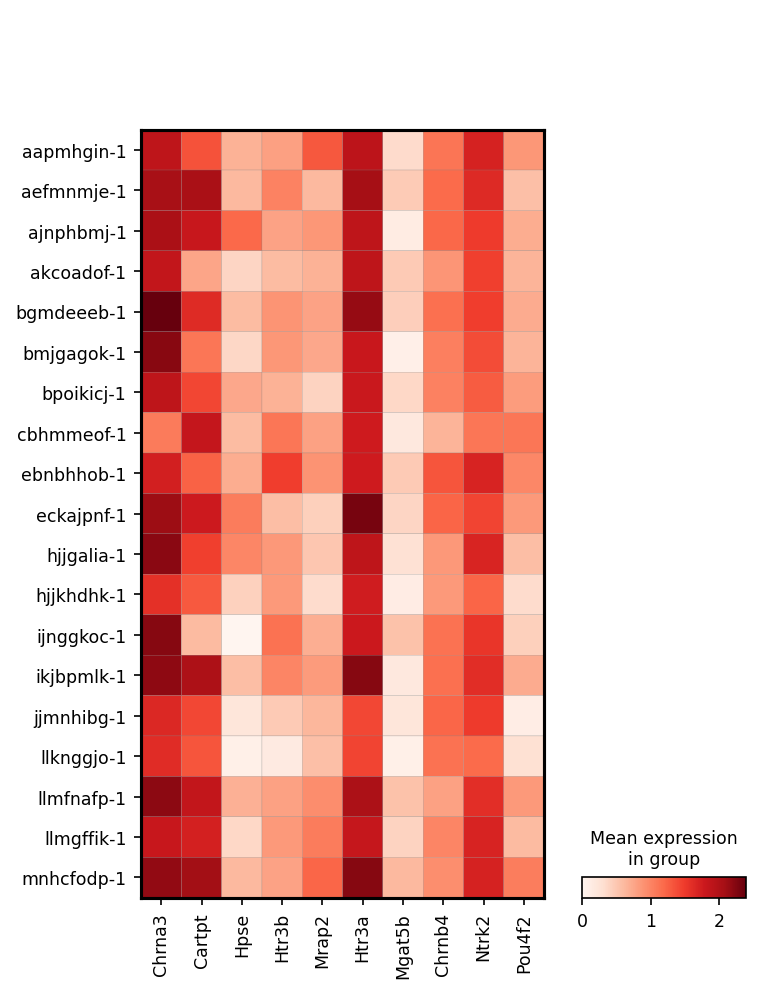

In [11]:
sc.pl.matrixplot(
    adata,
    var_names=genes,
    groupby="dual_cell_id",
    cmap="Reds",
)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 475 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


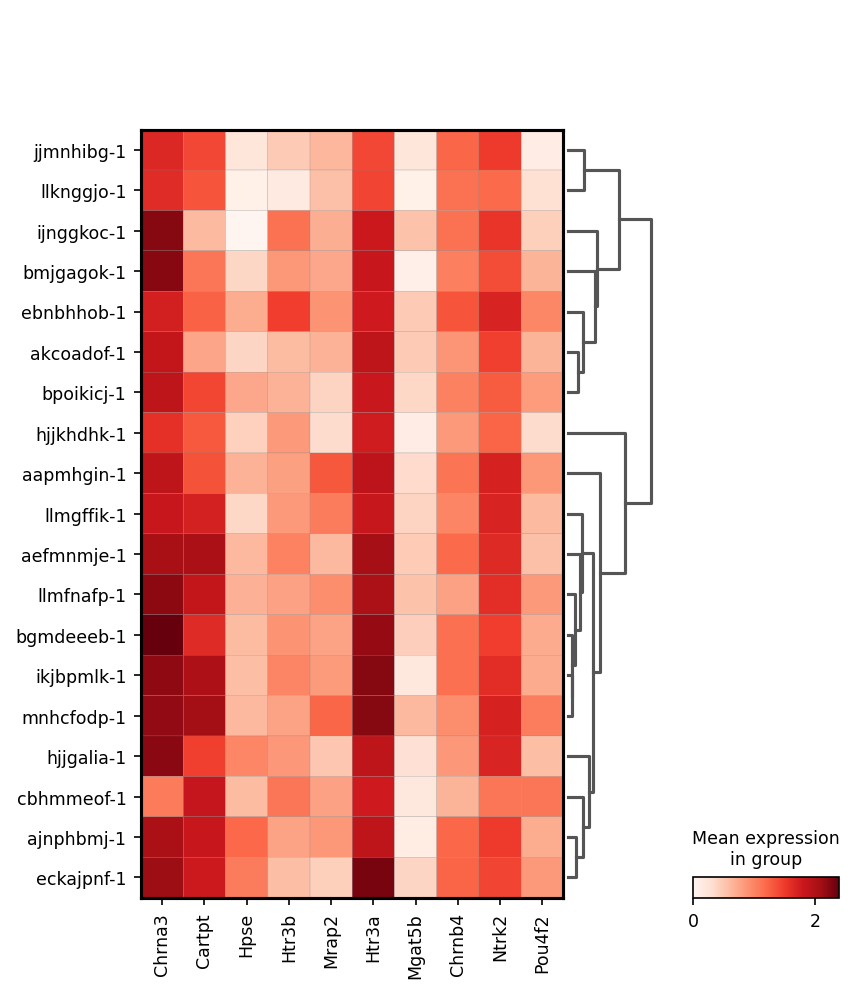

In [12]:
sc.pl.matrixplot(
    adata, var_names=genes, groupby="dual_cell_id", cmap="Reds", dendrogram=True
)

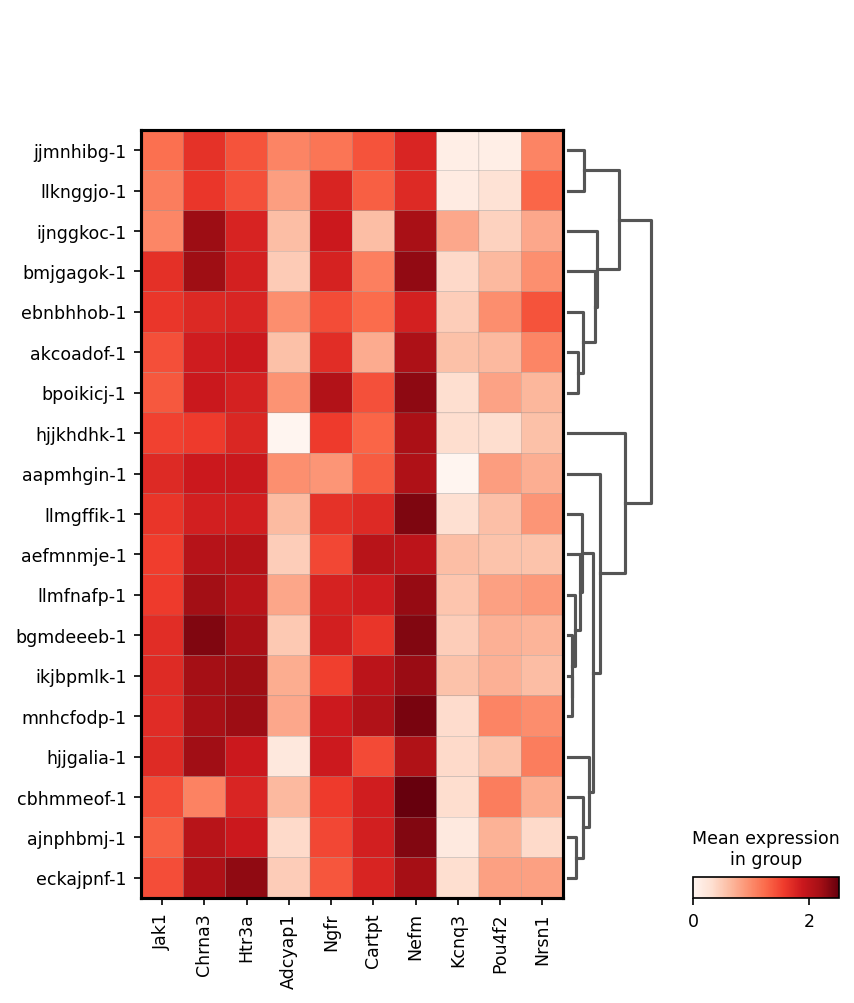

In [13]:
genes = [
    "Jak1",
    "Chrna3",
    "Htr3a",
    "Adcyap1",
    "Ngfr",
    "Cartpt",
    "Nefm",
    "Kcnq3",
    "Pou4f2",
    "Nrsn1",
]

sc.pl.matrixplot(
    adata, var_names=genes, groupby="dual_cell_id", cmap="Reds", dendrogram=True
)

In [16]:
adata.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch',
       '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels',
       'seurat_labels', 'prediction.score.CGRP.Theta',
       'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha',
       'prediction.score.Nonpeptidergic.nociceptors',
       'prediction.score.C.LTMR', 'prediction.score.Sst',
       'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion',
       'prediction.score.

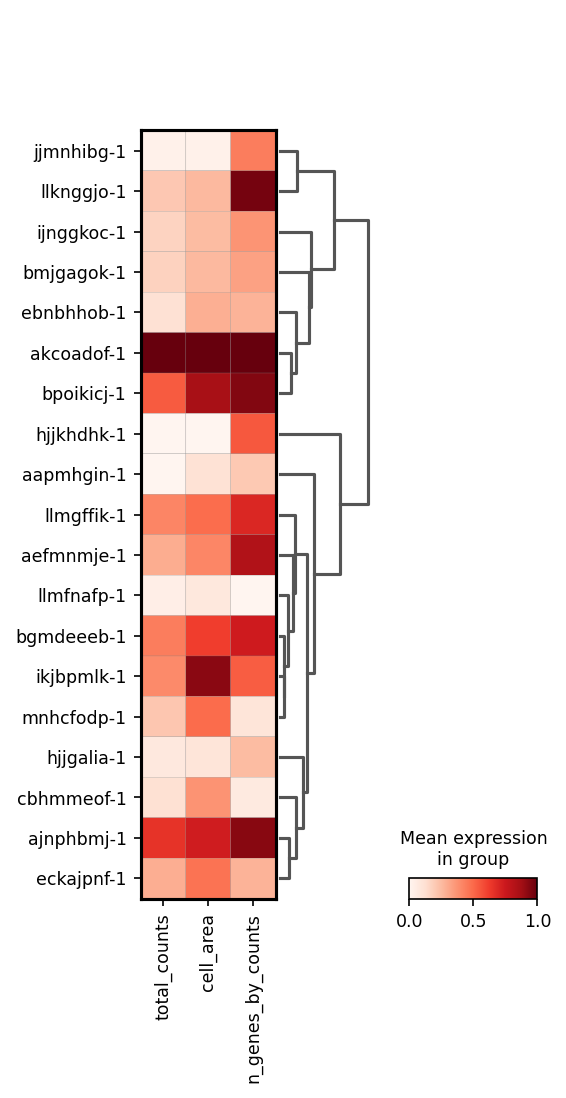

In [21]:
sc.pl.matrixplot(
    adata,
    var_names=["total_counts", "cell_area", "n_genes_by_counts"],
    groupby="dual_cell_id",
    cmap="Reds",
    dendrogram=True,
    standard_scale="var",
)